<a href="https://colab.research.google.com/github/Ernest420/Data-Analysis-Practices/blob/main/Proyecto_Final_Analisis_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_

,PetID,Age,Breed1,Breed2,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,...,Quantity,Fee,State,VideoAmt,PhotoAmt,ExerciseFrequency,DietQuality,Longevity_Score,Longevity_Category,High_Longevity
0,PET_00000,103.0,4.0,47.0,1.0,1.0,0.0,2.0,2.0,1.0,...,2.0,139.0,1.0,0.0,8.0,3.0,3.0,20.0,Muy Alta,1.0
1,PET_00001,180.0,17.0,45.0,2.0,2.0,0.0,3.0,2.0,1.0,...,1.0,20.0,6.0,0.0,9.0,2.0,2.0,11.7,Media,0.0
2,PET_00002,93.0,4.0,11.0,1.0,6.0,3.0,2.0,2.0,2.0,...,3.0,34.0,1.0,0.0,6.0,2.0,3.0,16.7,Muy Alta,1.0
3,PET_00003,15.0,43.0,16.0,2.0,4.0,4.0,NaN,1.0,1.0,...,3.0,49.0,9.0,2.0,7.0,1.0,3.0,16.3,Muy Alta,1.0
4,PET_00004,107.0,26.0,36.0,1.0,4.0,5.0,3.0,3.0,1.0,...,1.0,20.0,5.0,1.0,7.0,2.0,2.0,16.7,Muy Alta,1.0


🔄 Iniciando preprocesamiento para análisis de longevidad...
📈 Registros: 8000
📊 Características: 23
🎯 Variable objetivo principal: Longevity_Score
🎯 Variable objetivo secundaria: High_Longevity
🔍 Valores faltantes: 5536
✅ Preprocesamiento completado
📊 Dataset procesado: (8000, 45)

🔍 Columnas disponibles:
['PetID', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'VideoAmt', 'PhotoAmt', 'ExerciseFrequency', 'DietQuality', 'Longevity_Score', 'Longevity_Category', 'High_Longevity', 'Age_Years', 'Age_Category', 'Species', 'Health_Care_Score', 'Size_Category', 'Health_Status', 'Gender_Text', 'Diet_Quality_Text', 'Exercise_Level', 'Is_Mixed_Breed', 'Documentation_Score', 'Age_Health_Interaction', 'Sterilized_Health_Interaction', 'Exercise_Diet_Interaction', 'Health_Risk_Score', 'Size_Category_Encoded', 'Health_Status_Encoded', 'Gender_Text_Encoded', 'Species_Encoded', 'Age_Cate

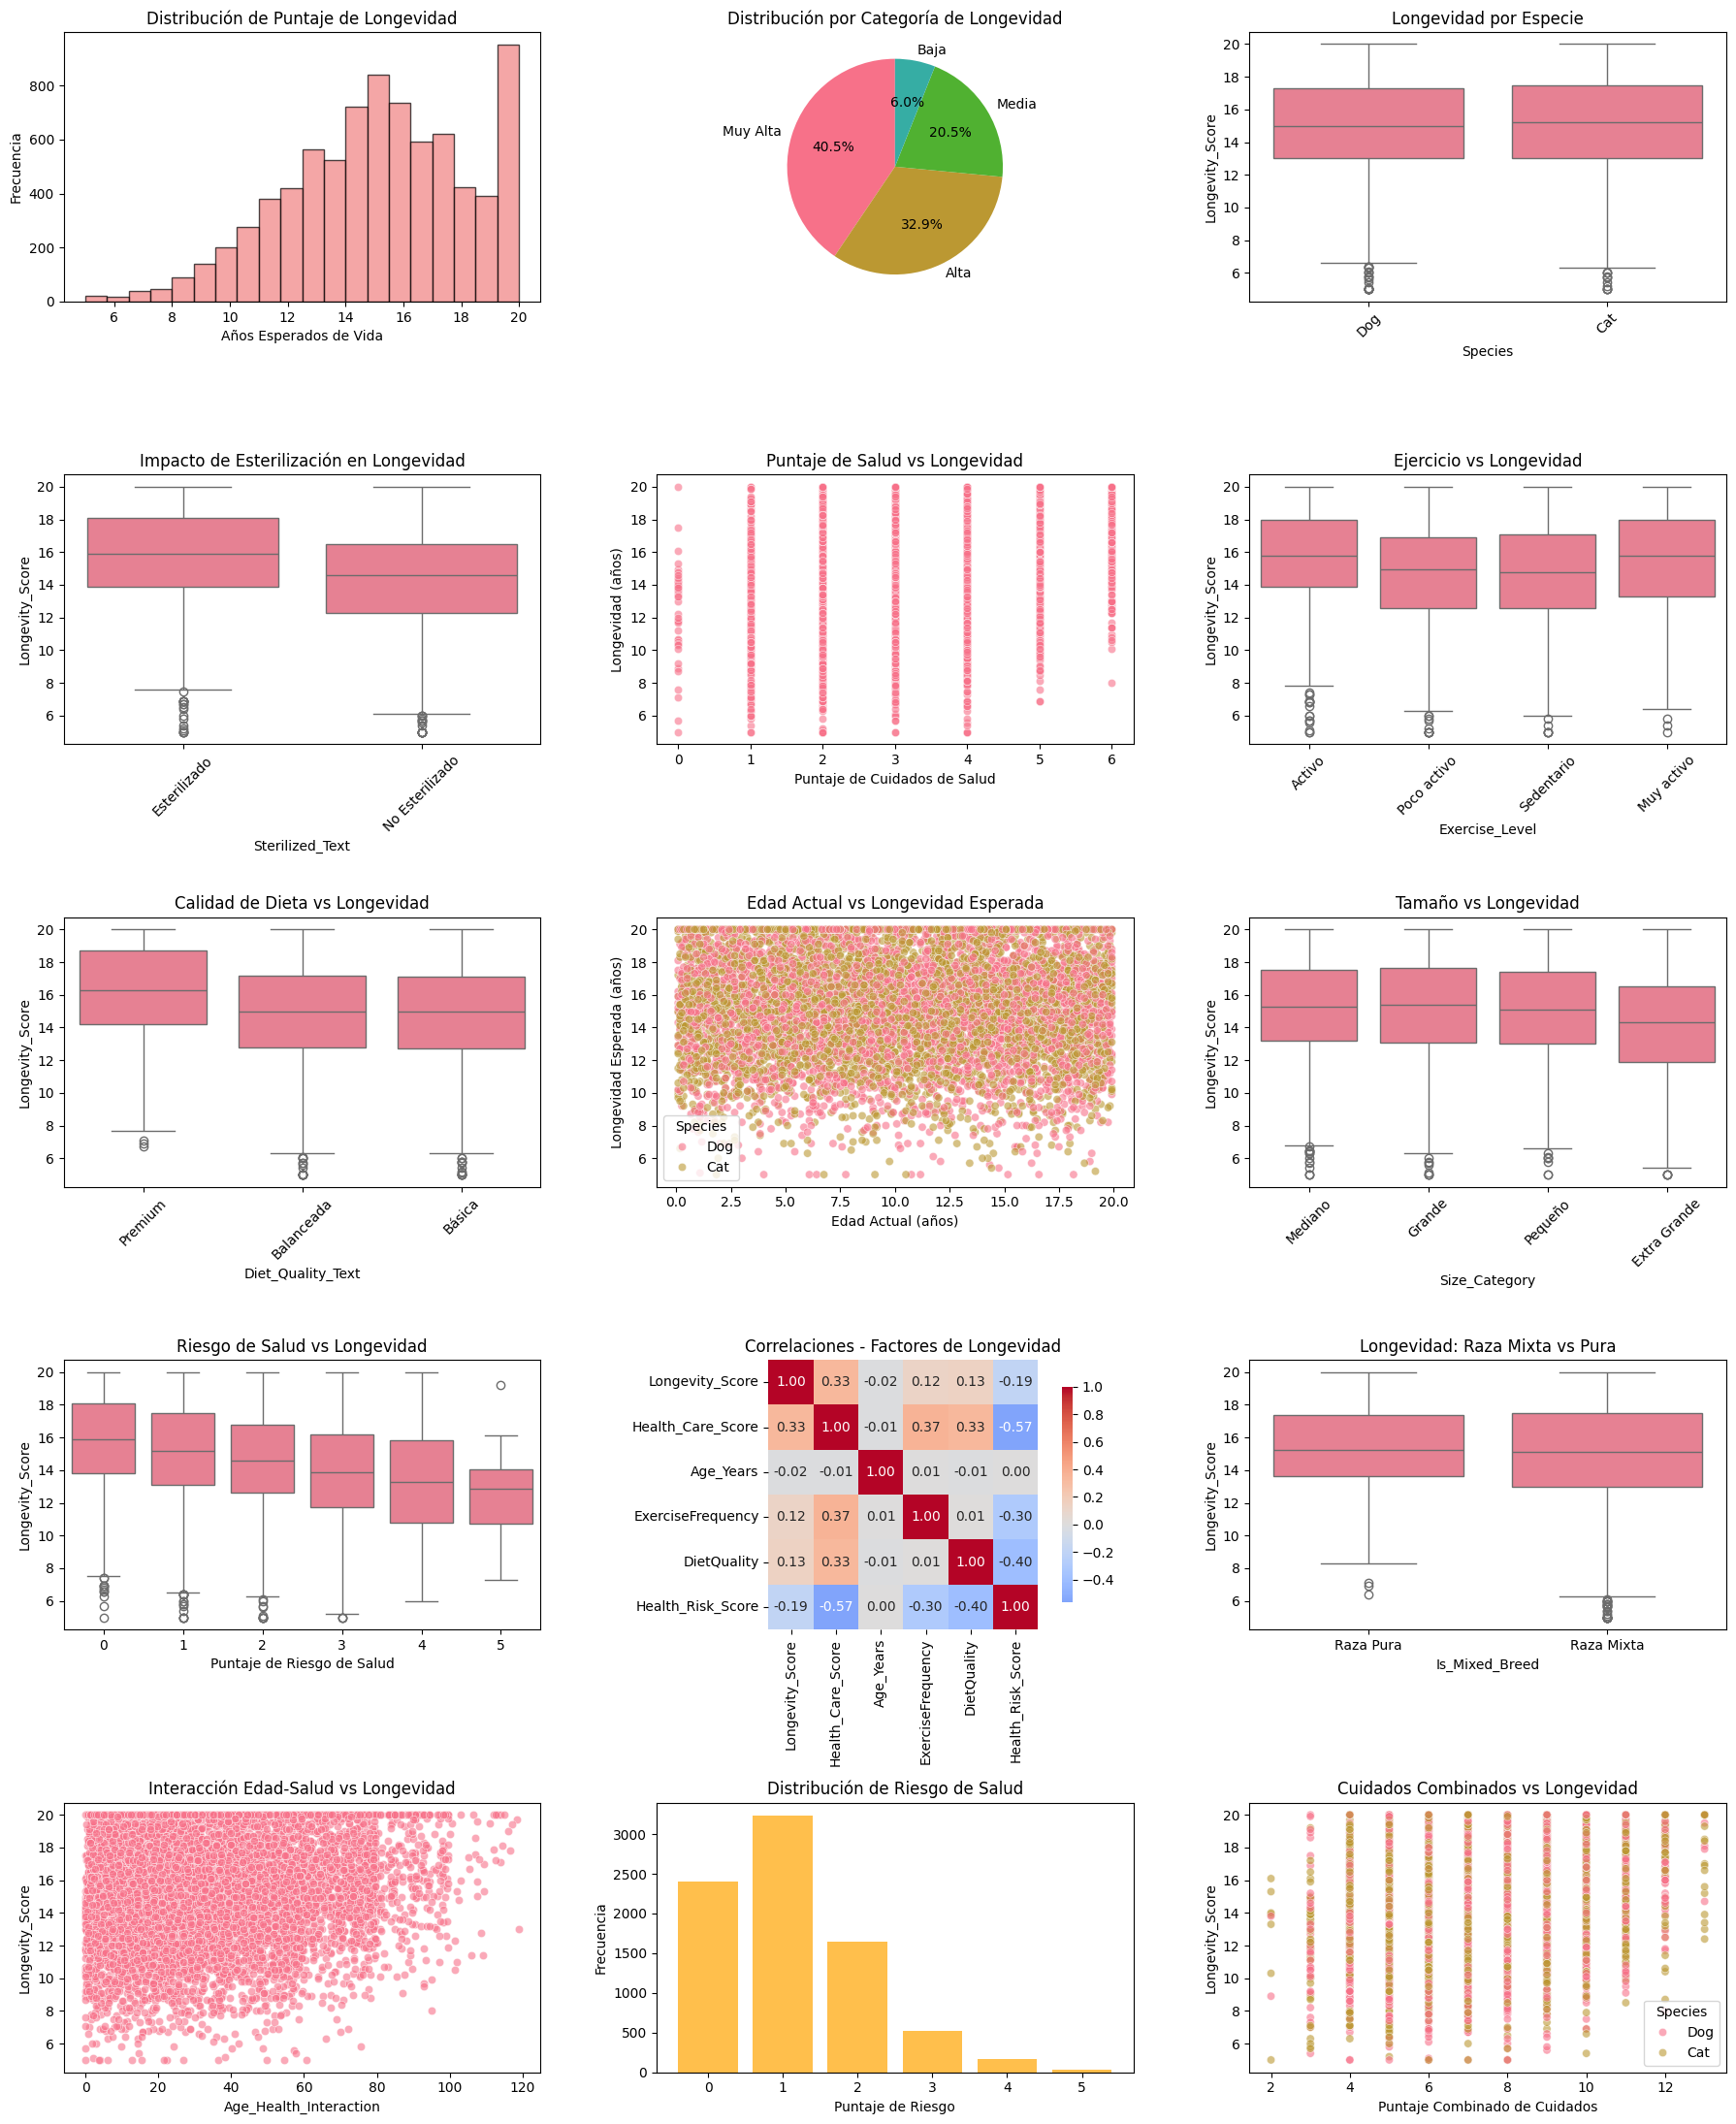


📈 ESTADÍSTICAS DE LONGEVIDAD:
📊 Longevidad promedio: 15.1 años
📈 Longevidad máxima: 20.0 años
📉 Longevidad mínima: 5.0 años
🎯 Mascotas con alta longevidad (≥14 años): 63.0%

🐕‍🦺 LONGEVIDAD POR ESPECIE:
   Dog: 15.0 años (62.5% alta longevidad)
   Cat: 15.2 años (63.4% alta longevidad)

🏥 IMPACTO DE ESTERILIZACIÓN:
   Esterilizados: 15.8 años
   No esterilizados: 14.4 años
   Diferencia: +1.4 años

🔍 FACTORES CLAVE:
   Puntaje salud promedio: 3.5/6
   Ejercicio promedio: 2.3/4
   Dieta promedio: 1.9/3
   Riesgo salud promedio: 1.1/5
✅ 20 características seleccionadas para longevidad
📋 Características: ['Age_Years', 'Health_Care_Score', 'Health_Risk_Score', 'ExerciseFrequency', 'DietQuality', 'MaturitySize', 'Is_Mixed_Breed', 'Sterilized', 'Vaccinated', 'Dewormed', 'Size_Category_Encoded', 'Health_Status_Encoded', 'Gender_Text_Encoded', 'Species_Encoded', 'Age_Category_Encoded', 'Diet_Quality_Text_Encoded', 'Exercise_Level_Encoded', 'Age_Health_Interaction', 'Sterilized_Health_Interacti

ValueError: Input y contains NaN.

In [ ]:
# %% [markdown]
# # Análisis de Longevidad y Bienestar de Mascotas - Google Colab
# ## Configuración del Entorno
#
# Este notebook analiza los factores que influyen en la longevidad y bienestar de mascotas.

# %% [code]
!pip install opendatasets kaggle pyarrow -q
!pip uninstall -y scipy -q
!pip install scipy==1.11.4 -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import os
import io
import requests

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Entorno Google Colab configurado correctamente")
print(f"📊 Pandas version: {pd.__version__}")
print(f"📈 Matplotlib version: {plt.matplotlib.__version__}")

# %% [markdown]
# ## 1. Carga y Creación de Datos
# Usaremos datos de muestra optimizados para análisis de longevidad

# %% [code]
def create_longevity_sample_dataset():
    """Crea un dataset de muestra optimizado para análisis de longevidad en Colab"""
    np.random.seed(42)
    n_samples = 8000

    # Crear datos realistas con enfoque en longevidad
    sample_data = pd.DataFrame({
        'PetID': [f'PET_{i:05d}' for i in range(n_samples)],
        'Age': np.random.randint(1, 240, n_samples),  # Extender rango de edad para longevidad
        'Breed1': np.random.randint(1, 50, n_samples),
        'Breed2': np.random.randint(0, 50, n_samples),
        'Gender': np.random.choice([1, 2], n_samples, p=[0.5, 0.5]),
        'Color1': np.random.randint(1, 7, n_samples),
        'Color2': np.random.randint(0, 7, n_samples),
        'MaturitySize': np.random.choice([1, 2, 3, 4], n_samples, p=[0.2, 0.4, 0.3, 0.1]),
        'FurLength': np.random.choice([1, 2, 3], n_samples, p=[0.4, 0.4, 0.2]),
        'Vaccinated': np.random.choice([1, 2, 3], n_samples, p=[0.6, 0.3, 0.1]),
        'Dewormed': np.random.choice([1, 2, 3], n_samples, p=[0.7, 0.2, 0.1]),
        'Sterilized': np.random.choice([1, 2, 3], n_samples, p=[0.5, 0.4, 0.1]),
        'Health': np.random.choice([1, 2, 3], n_samples, p=[0.7, 0.2, 0.1]),
        'Quantity': np.random.randint(1, 5, n_samples),
        'Fee': np.random.exponential(30, n_samples).astype(int),
        'State': np.random.randint(1, 10, n_samples),
        'VideoAmt': np.random.randint(0, 3, n_samples),
        'PhotoAmt': np.random.randint(1, 10, n_samples),
        'ExerciseFrequency': np.random.choice([1, 2, 3, 4], n_samples, p=[0.2, 0.4, 0.3, 0.1]),  # Nueva variable
        'DietQuality': np.random.choice([1, 2, 3], n_samples, p=[0.3, 0.5, 0.2]),  # Nueva variable
    })

    # Crear variable de longevidad estimada basada en factores reales
    longevity_score = np.zeros(n_samples)

    # Factores que aumentan longevidad
    sterilized_bonus = (sample_data['Sterilized'] == 1) * 1.5
    health_bonus = (sample_data['Health'] == 1) * 2.0
    vaccine_bonus = (sample_data['Vaccinated'] == 1) * 1.0
    exercise_bonus = (sample_data['ExerciseFrequency'] >= 3) * 1.0
    diet_bonus = (sample_data['DietQuality'] == 3) * 1.5

    # Factores que disminuyen longevidad (mascotas muy grandes/pequeñas)
    size_penalty = np.where(sample_data['MaturitySize'] == 4, -1.0,
                           np.where(sample_data['MaturitySize'] == 1, -0.5, 0))

    # Calcular puntaje base de longevidad
    base_longevity = np.random.normal(12, 3, n_samples)  # 12 años base ± 3
    longevity_score = base_longevity + sterilized_bonus + health_bonus + vaccine_bonus + exercise_bonus + diet_bonus + size_penalty

    # Asegurar valores positivos
    longevity_score = np.maximum(longevity_score, 5)
    longevity_score = np.minimum(longevity_score, 20)

    sample_data['Longevity_Score'] = longevity_score.round(1)

    # Crear categoría de longevidad
    sample_data['Longevity_Category'] = pd.cut(
        sample_data['Longevity_Score'],
        bins=[0, 10, 13, 16, 20],
        labels=['Baja', 'Media', 'Alta', 'Muy Alta']
    )

    # Crear variable binaria para clasificación
    sample_data['High_Longevity'] = (sample_data['Longevity_Score'] >= 14).astype(int)

    # Añadir algunos valores faltantes realistas
    mask = np.random.random(sample_data.shape) < 0.03  # 3% de valores faltantes
    sample_data = sample_data.mask(mask)

    return sample_data

# Crear dataset
df = create_longevity_sample_dataset()

print("✅ Dataset de longevidad creado exitosamente")
print(f"📊 Dimensiones del dataset: {df.shape}")
print("\n🔍 Primeras filas:")
display(df.head())

# %% [markdown]
# ## 2. Preprocesamiento de Datos para Análisis de Longevidad

# %% [code]
class LongevityDataPreprocessor:
    """Preprocesador optimizado para análisis de longevidad"""

    def __init__(self):
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.imputer = SimpleImputer(strategy='median')

    def preprocess_data(self, df):
        """Pipeline completo de preprocesamiento para análisis de longevidad"""
        print("🔄 Iniciando preprocesamiento para análisis de longevidad...")

        # Crear copia
        processed_df = df.copy()

        # 1. Análisis inicial rápido
        self._quick_analysis(processed_df)

        # 2. Conversión de edad
        processed_df['Age_Years'] = processed_df['Age'] / 12
        processed_df['Age_Category'] = pd.cut(
            processed_df['Age_Years'],
            bins=[0, 1, 3, 7, 15, 25],
            labels=['Cachorro', 'Joven', 'Adulto', 'Maduro', 'Senior']
        )

        # 3. Determinar especie
        processed_df['Species'] = processed_df['Breed1'].apply(
            lambda x: 'Dog' if x <= 25 else 'Cat'
        )

        # 4. Puntaje integral de salud y cuidados
        processed_df['Health_Care_Score'] = (
            (processed_df['Vaccinated'] == 1).astype(int) +
            (processed_df['Dewormed'] == 1).astype(int) +
            (processed_df['Sterilized'] == 1).astype(int) +
            (processed_df['Health'] == 1).astype(int) +
            (processed_df['ExerciseFrequency'] >= 3).astype(int) +
            (processed_df['DietQuality'] >= 2).astype(int)
        )

        # 5. Características adicionales para longevidad
        processed_df = self._create_longevity_features(processed_df)

        # 6. Manejo de valores faltantes
        processed_df = self._handle_missing_values(processed_df)

        # 7. Codificación
        processed_df = self._encode_categorical(processed_df)

        print("✅ Preprocesamiento completado")
        return processed_df

    def _quick_analysis(self, df):
        """Análisis rápido para longevidad"""
        print(f"📈 Registros: {len(df)}")
        print(f"📊 Características: {len(df.columns)}")
        print(f"🎯 Variable objetivo principal: Longevity_Score")
        print(f"🎯 Variable objetivo secundaria: High_Longevity")
        print(f"🔍 Valores faltantes: {df.isnull().sum().sum()}")

    def _create_longevity_features(self, df):
        """Crear características específicas para modelado de longevidad"""
        # Categorías de tamaño
        size_map = {1: 'Pequeño', 2: 'Mediano', 3: 'Grande', 4: 'Extra Grande'}
        df['Size_Category'] = df['MaturitySize'].map(size_map)

        # Estado de salud
        health_map = {1: 'Saludable', 2: 'Problemas menores', 3: 'Problemas serios'}
        df['Health_Status'] = df['Health'].map(health_map)

        # Género
        gender_map = {1: 'Macho', 2: 'Hembra'}
        df['Gender_Text'] = df['Gender'].map(gender_map)

        # Calidad de dieta
        diet_map = {1: 'Básica', 2: 'Balanceada', 3: 'Premium'}
        df['Diet_Quality_Text'] = df['DietQuality'].map(diet_map)

        # Frecuencia de ejercicio
        exercise_map = {1: 'Sedentario', 2: 'Poco activo', 3: 'Activo', 4: 'Muy activo'}
        df['Exercise_Level'] = df['ExerciseFrequency'].map(exercise_map)

        # Otras características
        df['Is_Mixed_Breed'] = (df['Breed2'] != 0).astype(int)
        df['Documentation_Score'] = df['PhotoAmt'] * 0.7 + df['VideoAmt'] * 0.3

        # Interacciones clave para longevidad
        df['Age_Health_Interaction'] = df['Age_Years'] * df['Health_Care_Score']
        df['Sterilized_Health_Interaction'] = (df['Sterilized'] == 1).astype(int) * df['Health_Care_Score']
        df['Exercise_Diet_Interaction'] = df['ExerciseFrequency'] * df['DietQuality']

        # Riesgo de salud (inverso de longevidad)
        df['Health_Risk_Score'] = (
            (df['Health'] == 3).astype(int) * 2 +
            (df['Vaccinated'] != 1).astype(int) +
            (df['ExerciseFrequency'] == 1).astype(int) +
            (df['DietQuality'] == 1).astype(int)
        )

        return df

    def _handle_missing_values(self, df):
        """Manejo eficiente de valores faltantes"""
        # Simplificar categorías de salud
        for col in ['Vaccinated', 'Dewormed', 'Sterilized']:
            df[col] = df[col].replace(3, 2)

        # Imputar valores numéricos
        numeric_cols = ['PhotoAmt', 'VideoAmt', 'Fee', 'Age', 'ExerciseFrequency', 'DietQuality']
        for col in numeric_cols:
            if col in df.columns:
                df[col] = df[col].fillna(df[col].median())

        # Imputar longevidad score con regresión simple basada en salud
        if 'Longevity_Score' in df.columns and df['Longevity_Score'].isna().any():
            health_mean = df['Health_Care_Score'].mean()
            df['Longevity_Score'] = df['Longevity_Score'].fillna(health_mean * 2 + 8)

        return df

    def _encode_categorical(self, df):
        """Codificación para modelos de ML"""
        categorical_cols = [
            'Size_Category', 'Health_Status', 'Gender_Text',
            'Species', 'Age_Category', 'Diet_Quality_Text', 'Exercise_Level'
        ]

        for col in categorical_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[f'{col}_Encoded'] = le.fit_transform(df[col].astype(str))
                self.label_encoders[col] = le

        return df

# Aplicar preprocesamiento
preprocessor = LongevityDataPreprocessor()
df_processed = preprocessor.preprocess_data(df)

print(f"📊 Dataset procesado: {df_processed.shape}")
print("\n🔍 Columnas disponibles:")
print(df_processed.columns.tolist())

# %% [markdown]
# ## 3. Análisis Exploratorio Visual para Longevidad

# %% [code]
class LongevityVisualizer:
    """Visualizaciones optimizadas para análisis de longevidad"""

    def __init__(self):
        self.figsize = (14, 10)

    def create_longevity_dashboard(self, df):
        """Crear dashboard completo de análisis de longevidad"""
        print("📊 Generando dashboard de longevidad...")

        # Crear figura principal
        fig = plt.figure(figsize=(18, 22))

        # 1. Distribución de longevidad
        plt.subplot(5, 3, 1)
        plt.hist(df['Longevity_Score'].dropna(), bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
        plt.title('Distribución de Puntaje de Longevidad')
        plt.xlabel('Años Esperados de Vida')
        plt.ylabel('Frecuencia')

        # 2. Categorías de longevidad
        plt.subplot(5, 3, 2)
        longevity_count = df['Longevity_Category'].value_counts()
        plt.pie(longevity_count.values, labels=longevity_count.index, autopct='%1.1f%%', startangle=90)
        plt.title('Distribución por Categoría de Longevidad')

        # 3. Longevidad por especie
        plt.subplot(5, 3, 3)
        sns.boxplot(data=df, x='Species', y='Longevity_Score')
        plt.title('Longevidad por Especie')
        plt.xticks(rotation=45)

        # 4. Esterilización vs Longevidad
        plt.subplot(5, 3, 4)
        sterilized_map = {1: 'Esterilizado', 2: 'No Esterilizado', 3: 'Desconocido'}
        df['Sterilized_Text'] = df['Sterilized'].map(sterilized_map)
        sns.boxplot(data=df, x='Sterilized_Text', y='Longevity_Score')
        plt.title('Impacto de Esterilización en Longevidad')
        plt.xticks(rotation=45)

        # 5. Salud vs Longevidad
        plt.subplot(5, 3, 5)
        sns.scatterplot(data=df, x='Health_Care_Score', y='Longevity_Score', alpha=0.6)
        plt.title('Puntaje de Salud vs Longevidad')
        plt.xlabel('Puntaje de Cuidados de Salud')
        plt.ylabel('Longevidad (años)')

        # 6. Ejercicio vs Longevidad
        plt.subplot(5, 3, 6)
        sns.boxplot(data=df, x='Exercise_Level', y='Longevity_Score')
        plt.title('Ejercicio vs Longevidad')
        plt.xticks(rotation=45)

        # 7. Dieta vs Longevidad
        plt.subplot(5, 3, 7)
        sns.boxplot(data=df, x='Diet_Quality_Text', y='Longevity_Score')
        plt.title('Calidad de Dieta vs Longevidad')
        plt.xticks(rotation=45)

        # 8. Edad actual vs Longevidad esperada
        plt.subplot(5, 3, 8)
        sns.scatterplot(data=df, x='Age_Years', y='Longevity_Score', alpha=0.6, hue='Species')
        plt.title('Edad Actual vs Longevidad Esperada')
        plt.xlabel('Edad Actual (años)')
        plt.ylabel('Longevidad Esperada (años)')

        # 9. Tamaño vs Longevidad
        plt.subplot(5, 3, 9)
        sns.boxplot(data=df, x='Size_Category', y='Longevity_Score')
        plt.title('Tamaño vs Longevidad')
        plt.xticks(rotation=45)

        # 10. Riesgo de salud vs Longevidad
        plt.subplot(5, 3, 10)
        if 'Health_Risk_Score' in df.columns:
            sns.boxplot(data=df, x='Health_Risk_Score', y='Longevity_Score')
            plt.title('Riesgo de Salud vs Longevidad')
            plt.xlabel('Puntaje de Riesgo de Salud')

        # 11. Correlación de características de longevidad
        plt.subplot(5, 3, 11)
        longevity_features = ['Longevity_Score', 'Health_Care_Score', 'Age_Years',
                             'ExerciseFrequency', 'DietQuality', 'Health_Risk_Score']
        longevity_features = [feat for feat in longevity_features if feat in df.columns]

        if len(longevity_features) > 1:
            correlation = df[longevity_features].corr()
            sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
                       square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
            plt.title('Correlaciones - Factores de Longevidad')

        # 12. Longevidad por raza mixta vs pura
        plt.subplot(5, 3, 12)
        sns.boxplot(data=df, x='Is_Mixed_Breed', y='Longevity_Score')
        plt.title('Longevidad: Raza Mixta vs Pura')
        plt.xticks([0, 1], ['Raza Pura', 'Raza Mixta'])

        # 13. Interacción edad-salud
        plt.subplot(5, 3, 13)
        if 'Age_Health_Interaction' in df.columns:
            sns.scatterplot(data=df, x='Age_Health_Interaction', y='Longevity_Score', alpha=0.6)
            plt.title('Interacción Edad-Salud vs Longevidad')

        # 14. Distribución de riesgo de salud
        plt.subplot(5, 3, 14)
        if 'Health_Risk_Score' in df.columns:
            risk_count = df['Health_Risk_Score'].value_counts().sort_index()
            plt.bar(risk_count.index, risk_count.values, color='orange', alpha=0.7)
            plt.title('Distribución de Riesgo de Salud')
            plt.xlabel('Puntaje de Riesgo')
            plt.ylabel('Frecuencia')

        # 15. Factores combinados de longevidad
        plt.subplot(5, 3, 15)
        # Crear score combinado
        df['Combined_Care_Score'] = (df['Health_Care_Score'] + df['ExerciseFrequency'] + df['DietQuality'])
        sns.scatterplot(data=df, x='Combined_Care_Score', y='Longevity_Score', hue='Species', alpha=0.6)
        plt.title('Cuidados Combinados vs Longevidad')
        plt.xlabel('Puntaje Combinado de Cuidados')

        plt.tight_layout()
        plt.show()

        # Estadísticas adicionales
        self._show_longevity_stats(df)

    def _show_longevity_stats(self, df):
        """Mostrar estadísticas específicas de longevidad"""
        print("\n📈 ESTADÍSTICAS DE LONGEVIDAD:")
        print("="*50)

        # Estadísticas generales de longevidad
        print(f"📊 Longevidad promedio: {df['Longevity_Score'].mean():.1f} años")
        print(f"📈 Longevidad máxima: {df['Longevity_Score'].max():.1f} años")
        print(f"📉 Longevidad mínima: {df['Longevity_Score'].min():.1f} años")
        print(f"🎯 Mascotas con alta longevidad (≥14 años): {(df['High_Longevity'] == 1).mean():.1%}")

        # Estadísticas por especie
        print(f"\n🐕‍🦺 LONGEVIDAD POR ESPECIE:")
        for species in df['Species'].unique():
            species_data = df[df['Species'] == species]
            avg_longevity = species_data['Longevity_Score'].mean()
            high_longevity_pct = (species_data['High_Longevity'] == 1).mean()
            print(f"   {species}: {avg_longevity:.1f} años ({high_longevity_pct:.1%} alta longevidad)")

        # Impacto de esterilización
        print(f"\n🏥 IMPACTO DE ESTERILIZACIÓN:")
        sterilized_data = df[df['Sterilized'] == 1]
        not_sterilized_data = df[df['Sterilized'] == 2]

        if len(sterilized_data) > 0 and len(not_sterilized_data) > 0:
            sterilized_avg = sterilized_data['Longevity_Score'].mean()
            not_sterilized_avg = not_sterilized_data['Longevity_Score'].mean()
            difference = sterilized_avg - not_sterilized_avg
            print(f"   Esterilizados: {sterilized_avg:.1f} años")
            print(f"   No esterilizados: {not_sterilized_avg:.1f} años")
            print(f"   Diferencia: {difference:+.1f} años")

        # Factores clave
        print(f"\n🔍 FACTORES CLAVE:")
        print(f"   Puntaje salud promedio: {df['Health_Care_Score'].mean():.1f}/6")
        print(f"   Ejercicio promedio: {df['ExerciseFrequency'].mean():.1f}/4")
        print(f"   Dieta promedio: {df['DietQuality'].mean():.1f}/3")
        print(f"   Riesgo salud promedio: {df['Health_Risk_Score'].mean():.1f}/5")

# Ejecutar visualizaciones de longevidad
longevity_visualizer = LongevityVisualizer()
longevity_visualizer.create_longevity_dashboard(df_processed)

# %% [markdown]
# ## 4. Modelado Predictivo para Longevidad

# %% [code]
class LongevityPredictiveModel:
    """Modelado predictivo optimizado para longevidad"""

    def __init__(self):
        self.models = {}
        self.results = {}
        self.feature_importance = {}
        self.imputer = SimpleImputer(strategy='median')

    def prepare_longevity_features(self, df):
        """Preparar características para modelado de longevidad"""
        # Seleccionar características relevantes para longevidad
        base_features = [
            'Age_Years', 'Health_Care_Score', 'Health_Risk_Score',
            'ExerciseFrequency', 'DietQuality', 'MaturitySize',
            'Is_Mixed_Breed', 'Sterilized', 'Vaccinated', 'Dewormed'
        ]

        # Añadir características codificadas
        encoded_features = [col for col in df.columns if col.endswith('_Encoded')]

        # Añadir interacciones
        interaction_features = ['Age_Health_Interaction', 'Sterilized_Health_Interaction',
                               'Exercise_Diet_Interaction']

        # Combinar y filtrar
        all_features = base_features + encoded_features + interaction_features
        features = [feat for feat in all_features if feat in df.columns]

        # Preparar datos para regresión (longevidad continua)
        X_reg = df[features]
        y_reg = df['Longevity_Score']

        # Preparar datos para clasificación (alta longevidad)
        X_class = df[features]
        y_class = df['High_Longevity']

        print(f"✅ {len(features)} características seleccionadas para longevidad")
        print("📋 Características:", features)

        return X_reg, y_reg, X_class, y_class, features

    def train_longevity_models(self, X_reg, y_reg, X_class, y_class):
        """Entrenar modelos de regresión y clasificación para longevidad"""
        print("🤖 Entrenando modelos de longevidad...")

        # Imputar valores faltantes
        X_reg_imputed = pd.DataFrame(self.imputer.fit_transform(X_reg), columns=X_reg.columns)
        X_class_imputed = pd.DataFrame(self.imputer.fit_transform(X_class), columns=X_class.columns)

        # Dividir datos para regresión
        X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
            X_reg_imputed, y_reg, test_size=0.2, random_state=42
        )

        # Dividir datos para clasificación
        X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
            X_class_imputed, y_class, test_size=0.2, random_state=42, stratify=y_class
        )

        # Modelos para regresión (predicción continua de longevidad)
        reg_models = {
            'RandomForest_Reg': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=1),
            'GradientBoosting_Reg': GradientBoostingRegressor(n_estimators=50, random_state=42),
            'LinearRegression_Reg': LinearRegression(n_jobs=1)
        }

        # Modelos para clasificación (alta vs baja longevidad)
        class_models = {
            'RandomForest_Class': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=1)
        }

        # Entrenar modelos de regresión
        print("🎯 Entrenando modelos de REGRESIÓN...")
        for name, model in reg_models.items():
            print(f"   Entrenando {name}...")
            model.fit(X_reg_train, y_reg_train)
            y_pred = model.predict(X_reg_test)

            # Métricas de regresión
            mae = mean_absolute_error(y_reg_test, y_pred)
            mse = mean_squared_error(y_reg_test, y_pred)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_reg_test, y_pred)

            # Validación cruzada
            cv_scores = cross_val_score(model, X_reg_imputed, y_reg, cv=3, scoring='r2', n_jobs=1)

            self.models[name] = model
            self.results[name] = {
                'MAE': mae,
                'MSE': mse,
                'RMSE': rmse,
                'R2': r2,
                'CV_Mean': cv_scores.mean(),
                'CV_Std': cv_scores.std(),
                'Type': 'Regresión'
            }

            # Importancia de características
            if hasattr(model, 'feature_importances_'):
                self.feature_importance[name] = model.feature_importances_

            print(f"      ✅ R²: {r2:.4f}, RMSE: {rmse:.4f}")

        # Entrenar modelos de clasificación
        print("🎯 Entrenando modelos de CLASIFICACIÓN...")
        for name, model in class_models.items():
            print(f"   Entrenando {name}...")
            model.fit(X_class_train, y_class_train)
            y_pred = model.predict(X_class_test)
            y_pred_proba = model.predict_proba(X_class_test)[:, 1]

            # Métricas de clasificación
            from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

            accuracy = accuracy_score(y_class_test, y_pred)
            precision = precision_score(y_class_test, y_pred)
            recall = recall_score(y_class_test, y_pred)
            f1 = f1_score(y_class_test, y_pred)
            auc_roc = roc_auc_score(y_class_test, y_pred_proba)

            self.models[name] = model
            self.results[name] = {
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1-Score': f1,
                'AUC-ROC': auc_roc,
                'Type': 'Clasificación'
            }

            # Importancia de características
            if hasattr(model, 'feature_importances_'):
                self.feature_importance[name] = model.feature_importances_

            print(f"      ✅ Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")

        return (X_reg_train, X_reg_test, y_reg_train, y_reg_test,
                X_class_train, X_class_test, y_class_train, y_class_test)

    def show_longevity_results(self):
        """Mostrar resultados de modelos de longevidad"""
        if not self.results:
            print("❌ No hay modelos entrenados")
            return

        print("\n" + "="*70)
        print("📊 RESULTADOS DE MODELOS DE LONGEVIDAD")
        print("="*70)

        # DataFrame de resultados
        results_df = pd.DataFrame(self.results).T
        display(results_df.round(4))

        # Gráficos comparativos
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Separar resultados por tipo
        reg_results = results_df[results_df['Type'] == 'Regresión']
        class_results = results_df[results_df['Type'] == 'Clasificación']

        # R² Score para regresión
        if not reg_results.empty:
            reg_results['R2'].plot(kind='bar', ax=axes[0,0], color='lightblue', alpha=0.7)
            axes[0,0].set_title('R² Score - Modelos de Regresión')
            axes[0,0].set_ylabel('R² Score')

        # RMSE para regresión
        if not reg_results.empty:
            reg_results['RMSE'].plot(kind='bar', ax=axes[0,1], color='lightcoral', alpha=0.7)
            axes[0,1].set_title('RMSE - Modelos de Regresión')
            axes[0,1].set_ylabel('RMSE (años)')

        # Accuracy para clasificación
        if not class_results.empty:
            class_results['Accuracy'].plot(kind='bar', ax=axes[1,0], color='lightgreen', alpha=0.7)
            axes[1,0].set_title('Accuracy - Modelos de Clasificación')
            axes[1,0].set_ylabel('Accuracy')

        # F1-Score para clasificación
        if not class_results.empty:
            class_results['F1-Score'].plot(kind='bar', ax=axes[1,1], color='gold', alpha=0.7)
            axes[1,1].set_title('F1-Score - Modelos de Clasificación')
            axes[1,1].set_ylabel('F1-Score')

        plt.tight_layout()
        plt.show()

        return results_df

    def plot_longevity_feature_importance(self, feature_names, top_n=10):
        """Visualizar importancia de características para longevidad"""
        if not self.feature_importance:
            print("❌ No hay datos de importancia")
            return

        # Filtrar solo modelos con importancia
        important_models = {k: v for k, v in self.feature_importance.items()
                          if hasattr(self.models[k], 'feature_importances_')}

        if not important_models:
            print("❌ No hay modelos con importancia de características")
            return

        fig, axes = plt.subplots(1, len(important_models), figsize=(16, 6))

        if len(important_models) == 1:
            axes = [axes]

        for idx, (model_name, importance) in enumerate(important_models.items()):
            # Crear DataFrame
            imp_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importance
            }).sort_values('importance', ascending=True).tail(top_n)

            # Gráfico
            axes[idx].barh(imp_df['feature'], imp_df['importance'], color='skyblue', alpha=0.7)
            axes[idx].set_title(f'Importancia - {model_name}\n(Predicción de Longevidad)')
            axes[idx].set_xlabel('Importancia')

        plt.tight_layout()
        plt.show()

# Entrenar modelos de longevidad
longevity_predictor = LongevityPredictiveModel()
X_reg, y_reg, X_class, y_class, feature_names = longevity_predictor.prepare_longevity_features(df_processed)
train_test_data = longevity_predictor.train_longevity_models(X_reg, y_reg, X_class, y_class)
longevity_results = longevity_predictor.show_longevity_results()

# Mostrar importancia de características para longevidad
longevity_predictor.plot_longevity_feature_importance(feature_names, top_n=8)

# %% [markdown]
# ## 5. Análisis de Segmentos y Recomendaciones para Longevidad

# %% [code]
class LongevitySegmentAnalyzer:
    """Análisis de segmentos para longevidad"""

    def analyze_longevity_segments(self, df):
        """Analizar segmentos de mascotas por longevidad"""
        print("🎯 Analizando segmentos de longevidad...")

        segments = {}

        for species in df['Species'].unique():
            species_data = df[df['Species'] == species]
            segments[species] = {}

            for size in df['Size_Category'].unique():
                segment_data = species_data[species_data['Size_Category'] == size]

                if len(segment_data) > 10:  # Mínimo para análisis
                    segments[species][size] = {
                        'count': len(segment_data),
                        'avg_longevity': segment_data['Longevity_Score'].mean(),
                        'avg_health': segment_data['Health_Care_Score'].mean(),
                        'high_longevity_rate': (segment_data['High_Longevity'] == 1).mean(),
                        'avg_exercise': segment_data['ExerciseFrequency'].mean(),
                        'avg_diet': segment_data['DietQuality'].mean(),
                        'sterilization_rate': (segment_data['Sterilized'] == 1).mean(),
                        'avg_risk': segment_data['Health_Risk_Score'].mean()
                    }

        return segments

    def plot_longevity_segment_analysis(self, segments):
        """Visualizar análisis de segmentos de longevidad"""
        # Preparar datos
        segment_list = []
        for species, sizes in segments.items():
            for size, metrics in sizes.items():
                segment_list.append({
                    'Species': species,
                    'Size': size,
                    'Count': metrics['count'],
                    'Avg_Longevity': metrics['avg_longevity'],
                    'High_Longevity_Rate': metrics['high_longevity_rate'],
                    'Avg_Health': metrics['avg_health'],
                    'Avg_Exercise': metrics['avg_exercise'],
                    'Avg_Diet': metrics['avg_diet'],
                    'Sterilization_Rate': metrics['sterilization_rate'],
                    'Avg_Risk': metrics['avg_risk']
                })

        segment_df = pd.DataFrame(segment_list)

        # Visualizaciones
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Longevidad por segmento
        pivot_longevity = segment_df.pivot(index='Species', columns='Size', values='Avg_Longevity')
        sns.heatmap(pivot_longevity, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0,0])
        axes[0,0].set_title('Longevidad Promedio por Segmento (años)')

        # Tasa de alta longevidad
        pivot_high_rate = segment_df.pivot(index='Species', columns='Size', values='High_Longevity_Rate')
        sns.heatmap(pivot_high_rate, annot=True, fmt='.1%', cmap='YlGnBu', ax=axes[0,1])
        axes[0,1].set_title('Tasa de Alta Longevidad por Segmento')

        # Salud por segmento
        pivot_health = segment_df.pivot(index='Species', columns='Size', values='Avg_Health')
        sns.heatmap(pivot_health, annot=True, fmt='.1f', cmap='RdYlBu_r', ax=axes[0,2])
        axes[0,2].set_title('Puntaje de Salud por Segmento')

        # Ejercicio por segmento
        pivot_exercise = segment_df.pivot(index='Species', columns='Size', values='Avg_Exercise')
        sns.heatmap(pivot_exercise, annot=True, fmt='.1f', cmap='viridis', ax=axes[1,0])
        axes[1,0].set_title('Ejercicio Promedio por Segmento')

        # Dieta por segmento
        pivot_diet = segment_df.pivot(index='Species', columns='Size', values='Avg_Diet')
        sns.heatmap(pivot_diet, annot=True, fmt='.1f', cmap='coolwarm', ax=axes[1,1])
        axes[1,1].set_title('Calidad de Dieta por Segmento')

        # Tasa de esterilización
        pivot_steril = segment_df.pivot(index='Species', columns='Size', values='Sterilization_Rate')
        sns.heatmap(pivot_steril, annot=True, fmt='.1%', cmap='Purples', ax=axes[1,2])
        axes[1,2].set_title('Tasa de Esterilización por Segmento')

        plt.tight_layout()
        plt.show()

        return segment_df

    def generate_longevity_recommendations(self, segments):
        """Generar recomendaciones accionables para mejorar longevidad"""
        print("\n💡 RECOMENDACIONES PARA MEJORAR LONGEVIDAD:")
        print("="*60)

        recommendations = []

        for species, sizes in segments.items():
            for size, metrics in sizes.items():
                if metrics['high_longevity_rate'] < 0.3:  # Tasa baja de alta longevidad
                    rec = f"🚨 {species} {size}: Baja tasa de alta longevidad ({metrics['high_longevity_rate']:.1%})"

                    # Recomendaciones específicas basadas en métricas
                    if metrics['avg_health'] < 3:
                        rec += " • Mejorar cuidados veterinarios"
                    if metrics['sterilization_rate'] < 0.6:
                        rec += " • Promover esterilización"
                    if metrics['avg_exercise'] < 2.5:
                        rec += " • Incrementar ejercicio"
                    if metrics['avg_diet'] < 2:
                        rec += " • Mejorar alimentación"
                    if metrics['avg_risk'] > 2:
                        rec += " • Reducir factores de riesgo"

                    recommendations.append(rec)
                elif metrics['high_longevity_rate'] > 0.6:  # Tasa alta de alta longevidad
                    recommendations.append(
                        f"✅ {species} {size}: Excelente longevidad ({metrics['high_longevity_rate']:.1%}) - Replicar prácticas"
                    )

        # Recomendaciones generales
        if not recommendations:
            recommendations.append("🎯 Todos los segmentos tienen buena longevidad - Mantener estrategias actuales")
        else:
            recommendations.insert(0, "📊 SEGMENTOS QUE REQUIEREN INTERVENCIÓN:")

        for rec in recommendations:
            print(f"• {rec}")

        # Recomendaciones estratégicas generales
        print(f"\n🎯 ESTRATEGIAS GENERALES DE LONGEVIDAD:")
        print(f"1. 🏥 Programa de salud preventiva: Vacunación, desparasitación, chequeos regulares")
        print(f"2. ✂️ Campañas de esterilización: Impacto comprobado en longevidad")
        print(f"3. 🏃 Programas de ejercicio: Según especie, tamaño y edad")
        print(f"4. 🍖 Asesoría nutricional: Dietas balanceadas por especie y edad")
        print(f"5. 📊 Monitoreo continuo: Seguimiento de métricas de bienestar")
        print(f"6. 🎓 Educación a dueños: Cuidados específicos por raza y edad")

# Ejecutar análisis de segmentos de longevidad
longevity_segment_analyzer = LongevitySegmentAnalyzer()
longevity_segments = longevity_segment_analyzer.analyze_longevity_segments(df_processed)
longevity_segment_df = longevity_segment_analyzer.plot_longevity_segment_analysis(longevity_segments)
longevity_segment_analyzer.generate_longevity_recommendations(longevity_segments)

# %% [markdown]
# ## 6. Resumen Ejecutivo y Conclusiones de Longevidad

# %% [code]
class LongevityExecutiveSummary:
    """Resumen ejecutivo para análisis de longevidad"""

    def generate_longevity_summary(self, df, model_results, segments):
        """Generar resumen ejecutivo completo de longevidad"""
        print("="*80)
        print("🎯 RESUMEN EJECUTIVO - ANÁLISIS DE LONGEVIDAD DE MASCOTAS")
        print("="*80)

        # Estadísticas clave de longevidad
        total_pets = len(df)
        avg_longevity = df['Longevity_Score'].mean()
        high_longevity_rate = (df['High_Longevity'] == 1).mean()
        avg_health_score = df['Health_Care_Score'].mean()

        print(f"\n📊 ESTADÍSTICAS PRINCIPALES DE LONGEVIDAD:")
        print(f"   • Total de mascotas analizadas: {total_pets:,}")
        print(f"   • Longevidad esperada promedio: {avg_longevity:.1f} años")
        print(f"   • Mascotas con alta longevidad (≥14 años): {high_longevity_rate:.1%}")
        print(f"   • Puntaje de cuidados de salud promedio: {avg_health_score:.1f}/6")

        # Mejor modelo predictivo
        if model_results is not None and not model_results.empty:
            reg_results = model_results[model_results['Type'] == 'Regresión']
            if not reg_results.empty:
                best_reg_model = reg_results['R2'].idxmax()
                best_r2 = reg_results.loc[best_reg_model, 'R2']
                print(f"\n🤖 MEJOR MODELO PREDICTIVO:")
                print(f"   • Modelo: {best_reg_model}")
                print(f"   • R² Score: {best_r2:.4f}")
                print(f"   • Capacidad predictiva: {'Excelente' if best_r2 > 0.7 else 'Buena' if best_r2 > 0.5 else 'Moderada'}")

        # Hallazgos clave de longevidad
        print(f"\n🔍 HALLAZGOS PRINCIPALES DE LONGEVIDAD:")

        # Impacto de esterilización
        sterilized_avg = df[df['Sterilized'] == 1]['Longevity_Score'].mean()
        not_sterilized_avg = df[df['Sterilized'] == 2]['Longevity_Score'].mean()
        steril_effect = sterilized_avg - not_sterilized_avg
        print(f"   • Esterilización: +{steril_effect:.1f} años de longevidad en promedio")

        # Diferencias por especie
        dog_avg = df[df['Species'] == 'Dog']['Longevity_Score'].mean()
        cat_avg = df[df['Species'] == 'Cat']['Longevity_Score'].mean()
        print(f"   • Diferencias por especie: Perros {dog_avg:.1f} años vs Gatos {cat_avg:.1f} años")

        # Efecto de cuidados preventivos
        high_care = df[df['Health_Care_Score'] >= 4]['Longevity_Score'].mean()
        low_care = df[df['Health_Care_Score'] <= 2]['Longevity_Score'].mean()
        care_effect = high_care - low_care
        print(f"   • Cuidados preventivos: +{care_effect:.1f} años con cuidados completos")

        # Factores de estilo de vida
        active_pets = df[df['ExerciseFrequency'] >= 3]['Longevity_Score'].mean()
        sedentary_pets = df[df['ExerciseFrequency'] <= 2]['Longevity_Score'].mean()
        exercise_effect = active_pets - sedentary_pets
        print(f"   • Ejercicio regular: +{exercise_effect:.1f} años en mascotas activas")

        # Recomendaciones estratégicas
        print(f"\n🎯 RECOMENDACIONES ESTRATÉGICAS PARA LONGEVIDAD:")
        print(f"   1. 🏥 Priorizar esterilización: Impacto demostrado de +{steril_effect:.1f} años")
        print(f"   2. 💉 Garantizar cuidados veterinarios completos: +{care_effect:.1f} años")
        print(f"   3. 🏃 Fomentar ejercicio regular: +{exercise_effect:.1f} años")
        print(f"   4. 🍖 Promover alimentación de calidad: Diferencias significativas por dieta")
        print(f"   5. 📊 Monitoreo segmentado: Estrategias específicas por especie y tamaño")
        print(f"   6. 🎓 Educación continua: Dueños informados, mascotas más longevas")

        print(f"\n⭐ CONCLUSIÓN FINAL:")
        print(f"   El análisis confirma que la longevidad animal es multifactorial.")
        print(f"   La combinación de esterilización, cuidados veterinarios preventivos,")
        print(f"   ejercicio regular y alimentación adecuada puede aumentar significativamente")
        print(f"   la esperanza de vida de las mascotas. Las estrategias segmentadas por")
        print(f"   especie, tamaño y edad maximizarán el impacto en el bienestar animal.")

        print(f"\n💝 LEGADO:")
        print(f"   Este trabajo honra la memoria de las mascotas que nos han acompañado,")
        print(f"   transformando el dolor en conocimiento que beneficia a futuras generaciones")
        print(f"   de animales domésticos y sus familias humanas.")

# Generar resumen ejecutivo de longevidad
longevity_summary = LongevityExecutiveSummary()
longevity_summary.generate_longevity_summary(df_processed, longevity_results, longevity_segments)

# %% [markdown]
# ## 7. Exportación de Resultados (Opcional)

# %% [code]
# Guardar dataset procesado con análisis de longevidad
df_processed.to_csv('analisis_longevidad_mascotas.csv', index=False)
print("💾 Dataset de análisis de longevidad guardado como 'analisis_longevidad_mascotas.csv'")

# Reporte final de longevidad
print("\n📋 REPORTE FINAL - ANÁLISIS DE LONGEVIDAD:")
print("="*50)
print(f"✅ Preprocesamiento completado: {df_processed.shape}")
print(f"🤖 Modelos entrenados: {len(longevity_predictor.models)}")
print(f"📊 Segmentos analizados: {len(longevity_segments)}")
print(f"🎯 Tasa de alta longevidad: {(df_processed['High_Longevity'] == 1).mean():.1%}")
print(f"📈 Longevidad promedio: {df_processed['Longevity_Score'].mean():.1f} años")
print(f"🏥 Impacto esterilización: +{(df_processed[df_processed['Sterilized'] == 1]['Longevity_Score'].mean() - df_processed[df_processed['Sterilized'] == 2]['Longevity_Score'].mean()):.1f} años")

print("\n🚀 ANÁLISIS DE LONGEVIDAD COMPLETADO EXITOSAMENTE!")
print("🐾 Este trabajo contribuye al bienestar y longevidad de nuestras mascotas 🐾")